#### [What the Fear & Greed Index Tells Us About Market Returns](https://medium.datadriveninvestor.com/what-the-fear-greed-index-tells-us-about-market-returns-8d75d5afebb0)

[CNN's Fear & Greed Index](https://www.cnn.com/markets/fear-and-greed) — a tool that measures market sentiment on a scale from `0` (extreme fear) to `100` (extreme greed).

In [1]:
# for data wrangling
import pandas as pd
import numpy as np
from datetime import datetime

# for plotting and visualizations
import plotly.express as px
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme() # to make the seaborn plots nicer

# for coloring heatmap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm

# For parsing data from financialmodelingprep api
import os
import requests, csv, json, urllib
from urllib.request import urlopen
import json

import warnings
warnings.filterwarnings('ignore')

In [2]:
def get_jsonparsed_data(url):
    response = urlopen(url)
    data = response.read().decode("utf-8")
    return json.loads(data)

In [3]:
# Financial Modeling Prep API url to obtain market returns data
fmp_base_url = "https://financialmodelingprep.com/api/v3/"

# CNN url for obtaining newer fear greed index data
cnn_base_url = "https://production.dataviz.cnn.io/index/fearandgreed/graphdata/"

# for obtaining older fear greed index data
# credits to Part Time Larry: https://github.com/hackingthemarkets
old_fear_greed_csv_url = 'https://raw.githubusercontent.com/hackingthemarkets/sentiment-fear-and-greed/refs/heads/master/datasets/fear-greed.csv'

In [4]:
df_index_old = pd.read_csv(old_fear_greed_csv_url)
df_index_old.to_csv('old_fear_greed.csv')
df_index_old = pd.read_csv('old_fear_greed.csv')
df_index_old = df_index_old[['Date', 'Fear Greed']]
df_index_old

,Date,Fear Greed
0,2011-01-03,68
1,2011-01-04,68
2,2011-01-05,67
3,2011-01-06,64
4,2011-01-07,63
...,...,...
2440,2020-09-14,59
2441,2020-09-15,59
2442,2020-09-16,56
2443,2020-09-17,53


In [5]:
start_date = "2020-09-19" # 1 day after last day of data in Part Time Larry's GitHub
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 6.1; WOW64; rv:20.0) Gecko/20100101 Firefox/20.0'}
r = requests.get(cnn_base_url + start_date, headers = headers)
data = r.json()

df_index_new = pd.DataFrame(data['fear_and_greed_historical']['data'])
df_index_new.head()

,x,y,rating
0,1.600646e+12,50.0,neutral
1,1.600733e+12,50.0,neutral
2,1.600819e+12,50.0,neutral
3,1.600906e+12,50.0,neutral
4,1.600992e+12,50.0,neutral


In [6]:
df_index_new['x'] = df_index_new['x'].apply(lambda x: datetime.fromtimestamp(x / 1000).strftime('%Y-%m-%d'))
df_index_new = df_index_new.rename(columns = {'x': 'Date', 'y': 'Fear Greed'})
df_index_new = df_index_new.drop_duplicates()
df_index = pd.concat([df_index_old, df_index_new])[['Date', 'Fear Greed']]
df_index['Date'] = pd.to_datetime(df_index['Date'])
df_index = df_index.set_index('Date')
df_index

,Fear Greed
Date,
2011-01-03,68.000000
2011-01-04,68.000000
2011-01-05,67.000000
2011-01-06,64.000000
2011-01-07,63.000000
...,...
2025-09-19,62.228571
2025-09-22,62.285714
2025-09-23,58.457143


<Axes: xlabel='Value of Fear & Greed Index', ylabel='Frequency'>

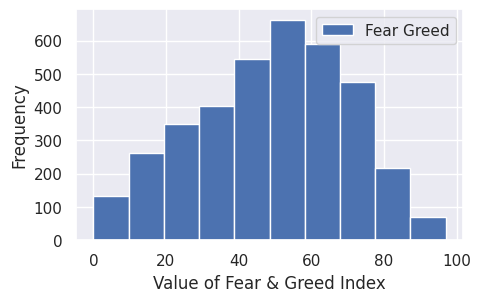

In [7]:
rcParams['figure.figsize'] = 5, 3
df_index.plot.hist(bins=10, xlabel = 'Value of Fear & Greed Index')

In [8]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']
df_index['fear_greed_bins'] = pd.cut(df_index['Fear Greed'], bins, labels=labels, include_lowest = True)

In [10]:
from google.colab import userdata
os.environ['FMP_API_KEY'] = userdata.get('FMP_API_KEY')

apiKey = os.environ['FMP_API_KEY']

In [11]:
ticker = "SPY"
earliest_date = df_index.index[0] # we extract data from the earliest date in our fear greed index data
earliest_date_string = earliest_date.strftime('%Y-%m-%d')
url = f"{fmp_base_url}historical-price-full/{ticker}?from={earliest_date_string}&apikey={apiKey}"
df_prices = pd.DataFrame(get_jsonparsed_data(url)['historical'])
df_prices['date'] = pd.to_datetime(df_prices['date']) # parse dates and set as index
df_prices = df_prices.set_index('date')
df_prices.head()

,open,high,low,close,adjClose,volume,unadjustedVolume,change,changePercent,vwap,label,changeOverTime
date,,,,,,,,,,,,
2025-09-24,664.51,664.61,659.67,661.10,661.10,68015100,68015100,-3.41,-0.513160,662.47,"September 24, 25",-0.005132
2025-09-23,666.72,667.34,661.98,663.21,663.21,81708900,81708900,-3.51,-0.526460,664.81,"September 23, 25",-0.005265
2025-09-22,662.20,667.29,662.17,666.84,666.84,69452201,69452201,4.64,0.700690,664.63,"September 22, 25",0.007007
2025-09-19,662.33,664.55,660.37,663.70,663.70,97945620,97945620,1.37,0.206850,662.74,"September 19, 25",0.002069
2025-09-18,661.89,664.89,660.27,662.26,660.43,90459242,90459242,0.37,0.055901,662.33,"September 18, 25",0.000559


In [12]:
timediff = {
    '1_day': 1,
    '1_week': 5,
    '1_month': 21, # 1 month has ~21 trading days
    '3_month': 63,
    '6_month': 126,
    '1_year': 252,
    '3_year': 756,
}

return_cols = [f'{x}_returns (%)' for x in timediff.keys()]

for label, shift_days in timediff.items():
    df_prices[label] = df_prices.shift(shift_days)['adjClose']
    df_prices[f'{label}_returns (%)'] = (df_prices[label] - df_prices['adjClose'])/df_prices['adjClose'] * 100 # in percent

df_prices[return_cols]

,1_day_returns (%),1_week_returns (%),1_month_returns (%),3_month_returns (%),6_month_returns (%),1_year_returns (%),3_year_returns (%)
date,,,,,,,
2025-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-23,-0.318150,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-22,-0.544358,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-19,0.473105,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-18,0.495132,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2011-01-07,-0.123014,1.701691,4.274731,4.951307,4.766786,2.808816,54.197847
2011-01-06,-0.194393,0.767342,3.591160,5.115613,6.486597,2.353182,53.478617
2011-01-05,-0.194016,0.735219,2.757071,5.177167,7.035638,2.420096,53.088941


In [13]:
df = df_index.merge(df_prices[return_cols],
                       left_index = True, right_index = True, how = 'left')

df.head()

,Fear Greed,fear_greed_bins,1_day_returns (%),1_week_returns (%),1_month_returns (%),3_month_returns (%),6_month_returns (%),1_year_returns (%),3_year_returns (%)
Date,,,,,,,,,
2011-01-03,68.0,61-70,-0.051293,-0.051293,2.708248,5.344686,6.298728,2.462043,52.821092
2011-01-04,68.0,61-70,0.513189,0.348968,2.986760,5.378220,6.486708,2.668583,53.833522
2011-01-05,67.0,61-70,-0.194016,0.735219,2.757071,5.177167,7.035638,2.420096,53.088941
2011-01-06,64.0,61-70,-0.194393,0.767342,3.591160,5.115613,6.486597,2.353182,53.478617
2011-01-07,63.0,61-70,-0.123014,1.701691,4.274731,4.951307,4.766786,2.808816,54.197847


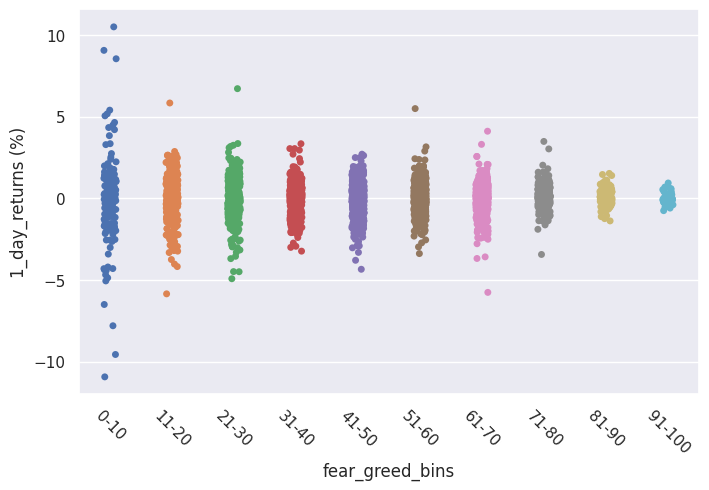

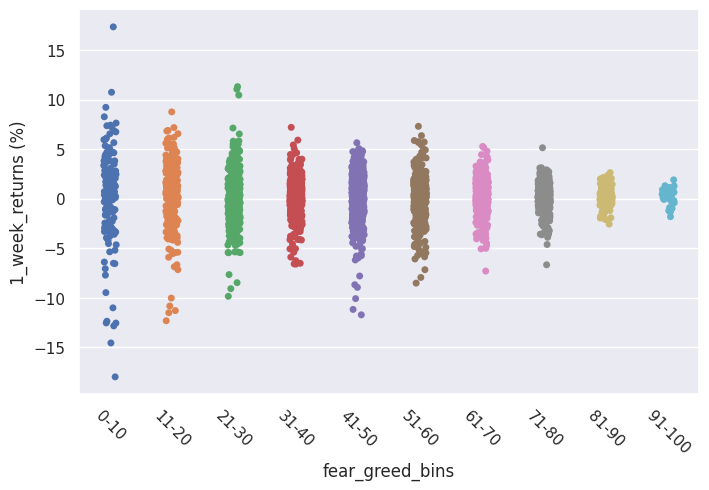

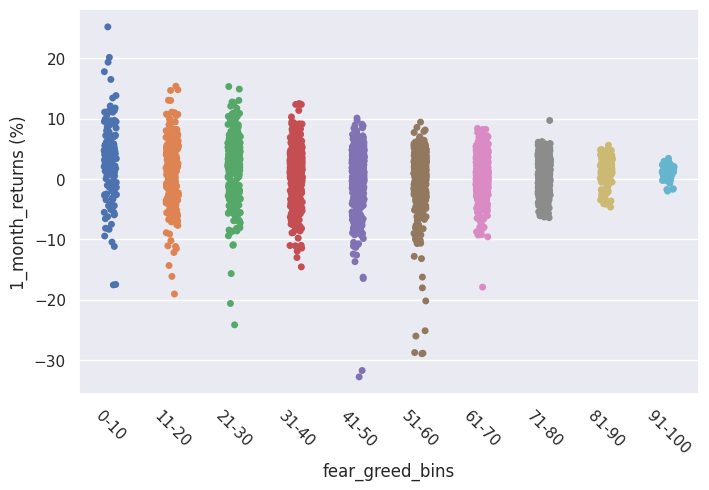

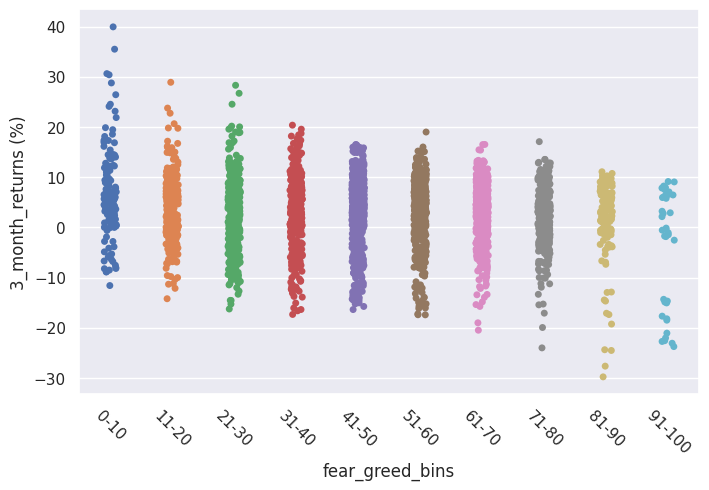

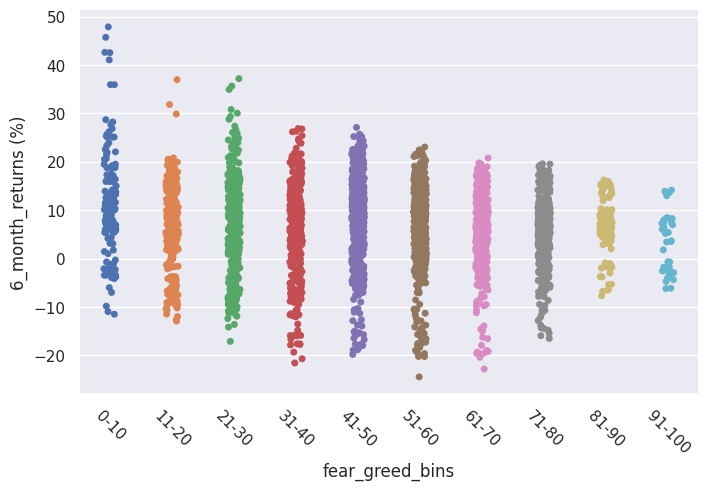

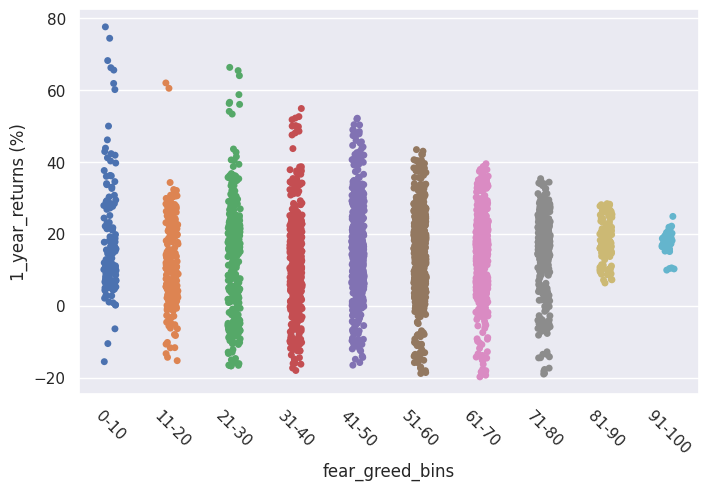

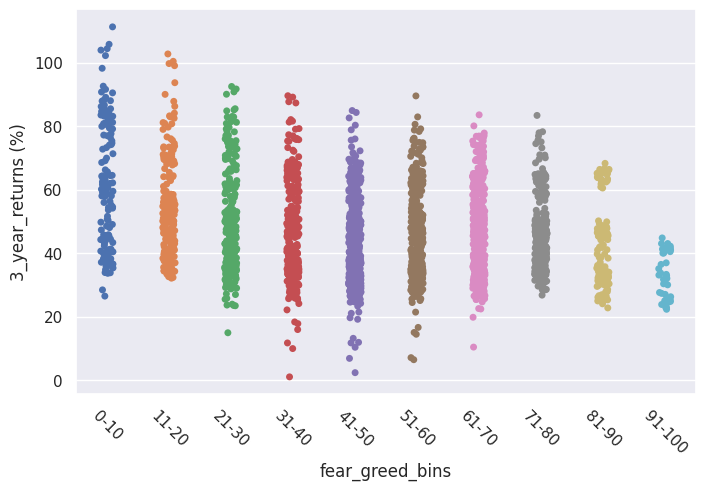

In [14]:
# figure size in inches
rcParams['figure.figsize'] = 8, 5

for label in timediff.keys():
    sns.stripplot(data=df.reset_index(), x='fear_greed_bins', y=f'{label}_returns (%)', hue='fear_greed_bins')
    plt.xticks(rotation=-45)
    plt.show()

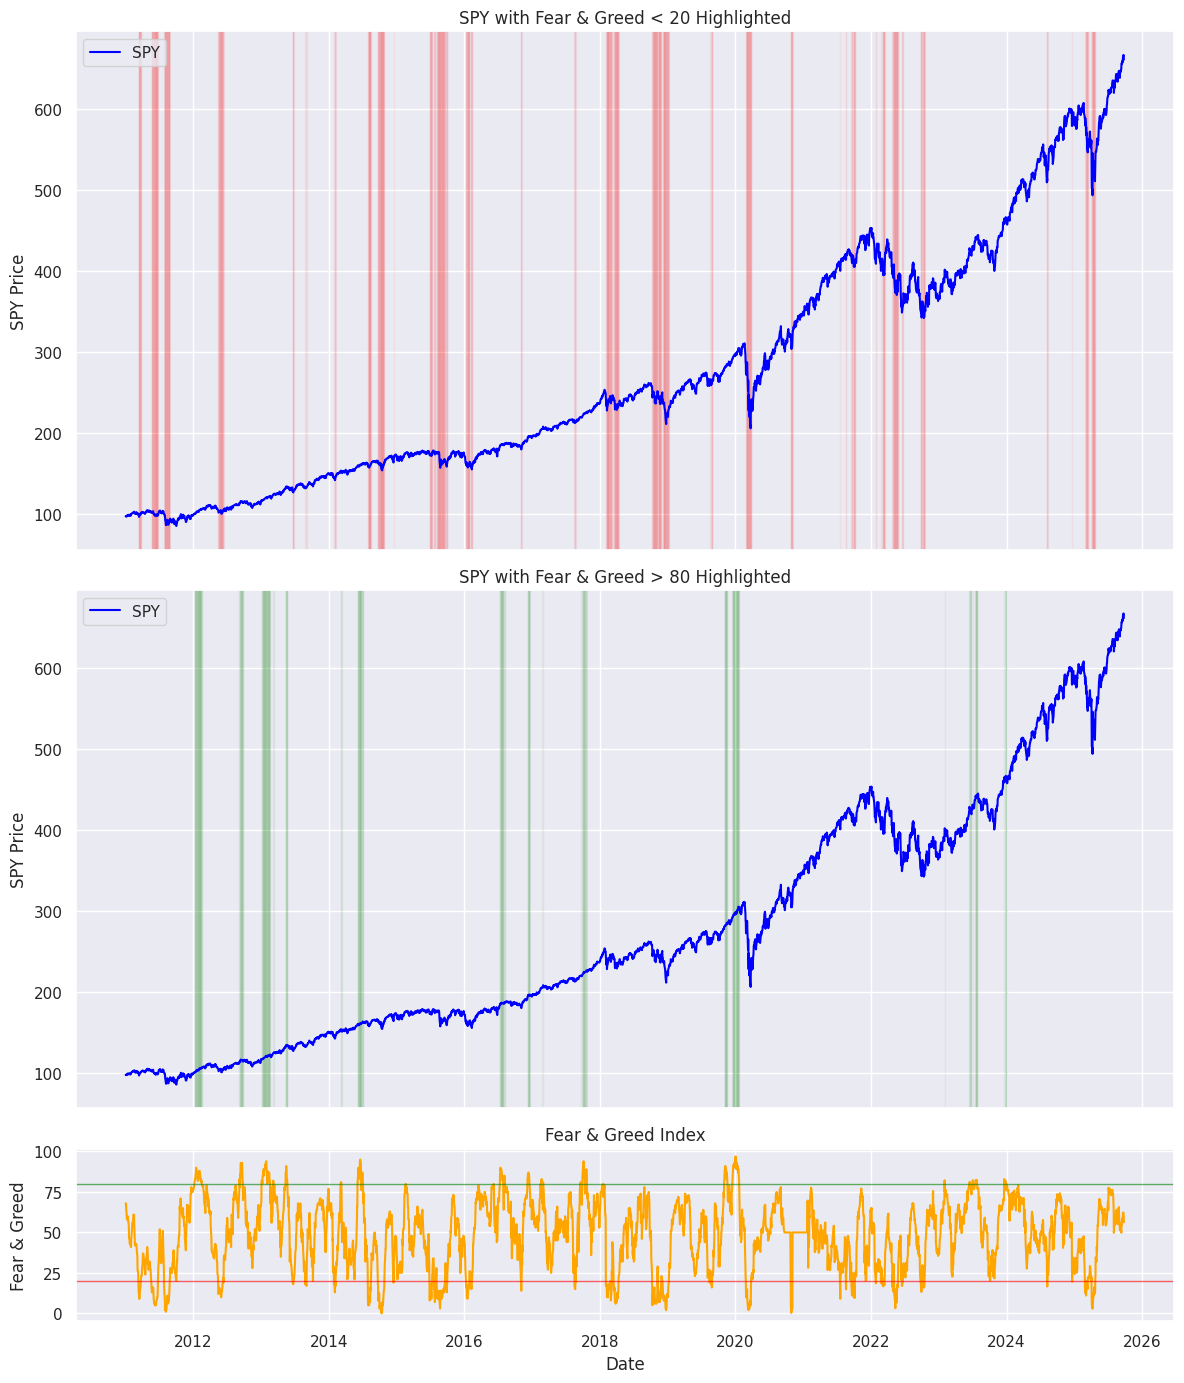

In [15]:
# for plotting
df_plot = df_index.merge(df_prices['adjClose'],
                       left_index = True, right_index = True, how = 'left')

rcParams['figure.figsize'] = (12, 14)

# 3 subplots, 2 for SPY, one for Fear Greed Index
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, sharex=True,
                                    gridspec_kw={'height_ratios': [3, 3, 1]})

# SPY with Red Highlight (< 20)
sns.lineplot(data=df_plot, x=df_plot.index, y='adjClose', ax=ax1, color='blue', label='SPY')
for i in range(len(df_plot) - 1):
    fg = df_plot['Fear Greed'].iloc[i]
    if fg < 20:
        x_start = df.index[i]
        x_end = df.index[i + 1]
        ax1.axvspan(x_start, x_end, color='red', alpha=0.05)
ax1.set_ylabel('SPY Price')
ax1.set_title('SPY with Fear & Greed < 20 Highlighted')
ax1.legend(loc='upper left')


# SPY with Green Highlight (> 80)
sns.lineplot(data=df_plot, x=df.index, y='adjClose', ax=ax2, color='blue', label='SPY')
for i in range(len(df_plot) - 1):
    fg = df_plot['Fear Greed'].iloc[i]
    if fg > 80:
        x_start = df_plot.index[i]
        x_end = df_plot.index[i + 1]
        ax2.axvspan(x_start, x_end, color='green', alpha=0.05)
ax2.set_ylabel('SPY Price')
ax2.set_title('SPY with Fear & Greed > 80 Highlighted')
ax2.legend(loc='upper left')


# Fear & Greed Index
sns.lineplot(data=df_plot, x=df_plot.index, y='Fear Greed', ax=ax3, color='orange')
# Add lines at 20 and 80
ax3.axhline(20, color='red', linewidth=1, alpha=0.6)
ax3.axhline(80, color='green', linewidth=1, alpha=0.6)
ax3.set_ylabel('Fear & Greed')
ax3.set_xlabel('Date')
ax3.set_title('Fear & Greed Index')

plt.tight_layout()
plt.show()

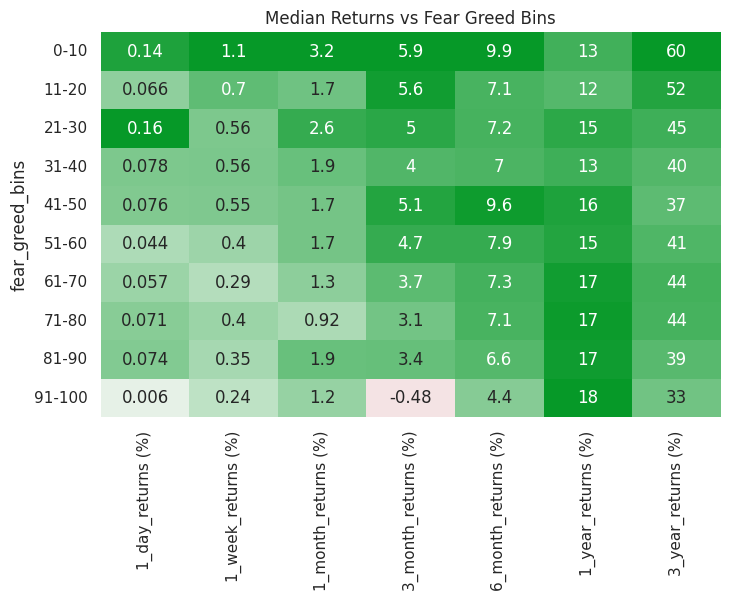

In [16]:
rcParams['figure.figsize'] = 8, 5
df_median = df.groupby('fear_greed_bins').median() # calculate the median for each decile
df_median_returns = df_median[return_cols]
df_median_returns = df_median[return_cols]

# we use this scaled_df to color the heatmap below, the coloring is scaled across each column
# as it is more meaningful to color the returns relative to other returns within the SAME PERIOD
scaled_df=df_median_returns/df_median_returns.max()
rdgn = sns.diverging_palette(h_neg=10, h_pos=130, s=99, l=55, sep=3, as_cmap=True)
divnorm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
sns.heatmap(scaled_df, annot=df_median_returns, cbar=False, cmap=rdgn, norm=divnorm)
plt.yticks(rotation=0)
plt.title("Median Returns vs Fear Greed Bins")
plt.show()

In [18]:
df_prices_stack = df_prices[return_cols].stack().reset_index()
df_prices_stack.columns = ['date', 'period', 'returns']
df_prices_stack = df_prices_stack.set_index('date')
df_prices_stack
df_stack = df_index.merge(df_prices_stack,
                       left_index = True, right_index = True)
df_stack

,Fear Greed,fear_greed_bins,period,returns
Date,,,,
2011-01-03,68.000000,61-70,1_day_returns (%),-0.051293
2011-01-03,68.000000,61-70,1_week_returns (%),-0.051293
2011-01-03,68.000000,61-70,1_month_returns (%),2.708248
2011-01-03,68.000000,61-70,3_month_returns (%),5.344686
2011-01-03,68.000000,61-70,6_month_returns (%),6.298728
...,...,...,...,...
2025-09-17,58.457143,51-60,1_week_returns (%),0.568942
2025-09-18,61.057143,61-70,1_day_returns (%),0.495132
2025-09-19,62.228571,61-70,1_day_returns (%),0.473105


In [19]:
rcParams['figure.figsize'] = 14, 12
fig = px.scatter(df_stack, x="Fear Greed", y="returns", animation_frame="period",
           color="fear_greed_bins", range_x=[0, 100], range_y=[-40, 130])
fig.update_layout(
    height=600, xaxis_title='Fear Greed Index', yaxis_title='Returns',
    title="Historical 1 Day to 3 Year Market Returns vs Fear Greed Index"
)
fig.show()